# Over-Fitting and Model Tuning

## Initializations

In [86]:
# Required packages
import pandas as pd       # For data handling
import numpy as np        # For numerical operations (optional but useful)
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns     # For nicer statistical plots
import scienceplots
from scipy.stats import skew
from scipy.stats import ttest_rel
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.preprocessing import PowerTransformer # For transformations 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA # For Principal Component Analysis
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate


import sys
import os

# Absolute path to the repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../"))

if repo_root not in sys.path:
    sys.path.append(repo_root)

from utils import check_transform_suitability, selective_transform, near_zero_var, find_correlation, plot_corr

# Set the plotting style
sns.set_theme(style="darkgrid")  # Set theme for seaborn plots

# Load data required for the analysis in this notebook
two_cd = pd.read_parquet("../../data/twoClassData.parquet")
german_credit = pd.read_parquet("../../data/GermanCredit.parquet")
chem_man_pro = pd.read_parquet("../../data/ChemicalManufacturingProcess.parquet")

## Investigate data

In [25]:
two_cd.head()

,classes,PredictorA,PredictorB
0,Class2,0.1582,0.1609
1,Class2,0.6552,0.4918
2,Class2,0.7060,0.6333
3,Class2,0.1992,0.0881
4,Class2,0.3952,0.4152


In [26]:
print(two_cd["classes"].unique(), "\n")      # List of unique class labels
print(two_cd["classes"].nunique())     # Number of unique classes
print(two_cd["classes"].value_counts()) # Frequency of each class

['Class2', 'Class1']
Categories (2, object): ['Class1', 'Class2'] 

2
classes
Class1    111
Class2     97
Name: count, dtype: int64


In [27]:
two_cd.describe()   # Summary statistics for numeric columns

,PredictorA,PredictorB
count,208.000000,208.000000
mean,0.250221,0.236013
std,0.140072,0.132705
min,0.023600,0.028900
25%,0.133475,0.129250
50%,0.249050,0.224800
75%,0.331250,0.301650
max,0.706000,0.734200


In [28]:
two_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   classes     208 non-null    category
 1   PredictorA  208 non-null    float64 
 2   PredictorB  208 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.7 KB


## Data Splitting

In [29]:
# Classes column contains the categorical labels
X = two_cd.drop(columns=["classes"])
y = two_cd["classes"]

# Stratified split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=0.8, 
    random_state=1,   # same as set.seed(1)
    stratify=y        # ensures class proportions are preserved
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("First few training indices:", X_train.index[:6])
print("First few test indices:", X_test.index[:6])

Train shape: (166, 2) (166,)
Test shape: (42, 2) (42,)
First few training indices: Index([183, 27, 149, 4, 94, 53], dtype='int64')
First few test indices: Index([45, 23, 74, 65, 204, 108], dtype='int64')


## Basic Model Building

### Fit a 5-nearest neighbor model, knn

In [30]:
knn_fit = KNeighborsClassifier(n_neighbors=5)
knn_fit.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
# Predict on test set
test_predictions = knn_fit.predict(X_test)
print("Test Predictions:", test_predictions)

Test Predictions: ['Class2' 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class1'
 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1' 'Class2' 'Class1'
 'Class1' 'Class1' 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1'
 'Class2' 'Class2' 'Class2' 'Class1' 'Class1' 'Class2' 'Class1' 'Class2'
 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class1' 'Class2'
 'Class1' 'Class1']


In [32]:
print(type(test_predictions))
print(test_predictions.shape)

<class 'numpy.ndarray'>
(42,)


### Predict class probabilities on test set

In [33]:
# This corresponds to the “proportion of neighbors for each class” mentioned for knn3:
# “The knn3 function can produce class predictions as well as the proportion of neighbors for each class.”
test_probabilities = knn_fit.predict_proba(X_test)
print(pd.DataFrame(test_probabilities, columns=knn_fit.classes_).head())

   Class1  Class2
0     0.4     0.6
1     0.2     0.8
2     0.2     0.8
3     0.0     1.0
4     1.0     0.0


### Evaluate model

Accuracy: 0.762
              precision    recall  f1-score   support

      Class1       0.73      0.86      0.79        22
      Class2       0.81      0.65      0.72        20

    accuracy                           0.76        42
   macro avg       0.77      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



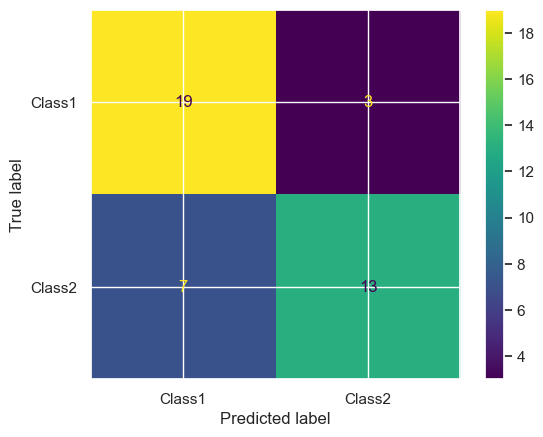

In [34]:
# Calculate accuracy: Proportion of correct predictions
accuracy = accuracy_score(y_test, test_predictions)
print(f"Accuracy: {accuracy:.3f}")

# The report contains precision, recall, f1-score, and support for each class
# precision: Of all instances predicted as positive, how many were actually positive?
# recall: How many of the actual positive instances were correctly predicted?
# f1-score: Harmonic mean of precision and recall
# support: Number of occurences in the dataset
print(classification_report(y_test, test_predictions))

# Confusion matrix can be used to visualize predicted labels vs true labels
ConfusionMatrixDisplay.from_estimator(knn_fit, X_test, y_test)


## Determination of Tuning Parameters (SVM example)

Section 4.6 illustrated parameter tuning for a support vector machine (SVM) using the credit scoring data. Using resampling, a value of the cost parameter was estimated.

For the credit scoring data, a radial basis function (RBF) kernel function was used for the SVM. This kernel function has an additional tuning parameter associated with it denoted as σ, which impacts the smoothness of the decision boundary. Normally, several combinations of both tuning parameters would be evaluated using resampling. However, Caputo et al. (2002) describe an analytical formula that can be used to get reasonable estimates of σ. The caret function train uses this approach to estimate the kernel parameter, leaving only the cost parameter for tuning.

### Investigation of data

In [35]:
german_credit.head()

,Duration,Amount,InstallmentRatePercentage,ResidenceDuration,Age,NumberExistingCredits,NumberPeopleMaintenance,Telephone,ForeignWorker,Class,...,OtherInstallmentPlans.Bank,OtherInstallmentPlans.Stores,OtherInstallmentPlans.None,Housing.Rent,Housing.Own,Housing.ForFree,Job.UnemployedUnskilled,Job.UnskilledResident,Job.SkilledEmployee,Job.Management.SelfEmp.HighlyQualified
0,6,1169,4,4,67,2,1,0.0,1.0,Good,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,48,5951,2,2,22,1,1,1.0,1.0,Bad,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,12,2096,2,3,49,1,2,1.0,1.0,Good,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,42,7882,2,4,45,1,2,1.0,1.0,Good,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,24,4870,3,4,53,2,2,1.0,1.0,Bad,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [36]:
german_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 62 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   Duration                                1000 non-null   int32   
 1   Amount                                  1000 non-null   int32   
 2   InstallmentRatePercentage               1000 non-null   int32   
 3   ResidenceDuration                       1000 non-null   int32   
 4   Age                                     1000 non-null   int32   
 5   NumberExistingCredits                   1000 non-null   int32   
 6   NumberPeopleMaintenance                 1000 non-null   int32   
 7   Telephone                               1000 non-null   float64 
 8   ForeignWorker                           1000 non-null   float64 
 9   Class                                   1000 non-null   category
 10  CheckingAccountStatus.lt.0              1000 non-

In [37]:
print(german_credit["Class"].value_counts()) # Frequency of each class

Class
Good    700
Bad     300
Name: count, dtype: int64


### Set up grid search

In [38]:
# First split data (not explicitely done in book)
X = german_credit.drop(columns=["Class"])
y = german_credit["Class"]

# Stratified split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=0.8, 
    random_state=1056,   # same as set.seed(1)
    stratify=y)       # ensures class proportions are preserved

In [39]:
# Define Preprocessing + Model Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),  # center and scale
    ("svm", SVC(kernel="rbf", class_weight='balanced')) # radial basis function kernel. class_weight='balanced' to handle class imbalance (not done in book)
])

In [40]:
# Define the Parameter Grid
C_values = [2 ** i for i in range(-2, 8)]
param_grid = {"svm__C": C_values}

# Note: scikit-learn’s SVC automatically tune gamma using its default 
# heuristic gamma='scale', which is analogous to caret’s use of Caputo’s analytical estimate.

In [41]:
# Define the Resampling Strategy
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=1056)

In [42]:
# Run Grid Search
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=1056),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128]},
             scoring='balanced_accuracy')

In [43]:
# Review the Results
results = pd.DataFrame(grid.cv_results_)
results = results[["param_svm__C", "mean_test_score", "std_test_score"]]
print(results)

   param_svm__C  mean_test_score  std_test_score
0          0.25         0.718452        0.047208
1          0.50         0.720714        0.047179
2          1.00         0.710060        0.049096
3          2.00         0.687500        0.048893
4          4.00         0.665179        0.047355
5          8.00         0.660774        0.052683
6         16.00         0.659702        0.054113
7         32.00         0.657560        0.051171
8         64.00         0.659405        0.050617
9        128.00         0.660060        0.050467


In [44]:
# Display the Best Model
print("Best C:", grid.best_params_["svm__C"])
print("Best accuracy:", grid.best_score_)
print("Best gamma (sigma):", grid.best_estimator_.named_steps["svm"]._gamma)


Best C: 0.5
Best accuracy: 0.7207142857142855
Best gamma (sigma): 0.01694915254237288


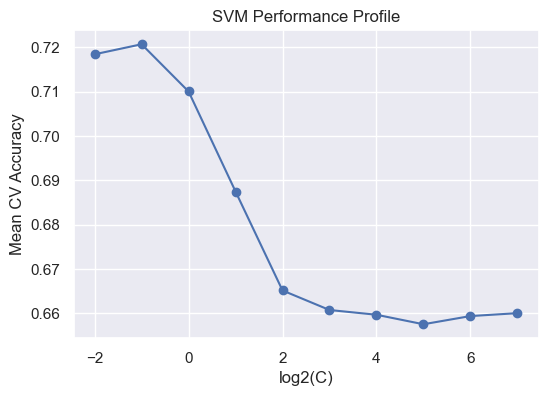

In [45]:
# Using results from the grid search to plot performance profile
results = grid.cv_results_

C_values = results['param_svm__C'].data.astype(float)
mean_acc = results['mean_test_score']

plt.figure(figsize=(6,4))
plt.plot(np.log2(C_values), mean_acc, marker='o')
plt.xlabel('log2(C)')
plt.ylabel('Mean CV Accuracy')
plt.title('SVM Performance Profile')
plt.grid(True)
plt.show()

In [46]:
# Evaluate on the Test Set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.705
              precision    recall  f1-score   support

         Bad       0.51      0.78      0.61        60
        Good       0.88      0.67      0.76       140

    accuracy                           0.70       200
   macro avg       0.69      0.73      0.69       200
weighted avg       0.77      0.70      0.72       200



### Training of Final Model

There are 2 ways to define the final model. grid.best_estimator_ already includes scaling and the tuned C and could be used directly as such:

```r
final_svm = grid.best_estimator_
```

This is a simple approach, but does now allow for subsequent probability estimation, which could be achieved by setting `probability=True` (see below). This however would trigger Platt scaling which involves an internal cross-validation step (on the training data) to estimate probabilities, which introduces randomness (we can set seed with random_state as below) and increases computation time. Nothing is gained from including `probability=True` in the grid search, unless a probability-based scoring metric (e.g., log-loss) is used to tune based on probability predictions instead of hard labels.

In [47]:
# Define the final model 
final_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel='rbf',
        C=0.5,
        gamma=0.01694915254237288,
        class_weight='balanced',
        probability=True,
        random_state=1056
    ))
])

final_svm.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=0.5, class_weight='balanced', gamma=0.01694915254237288,
                     probability=True, random_state=1056))])

In [48]:
# Evaluate on the Test Set
y_pred = final_svm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.705
              precision    recall  f1-score   support

         Bad       0.51      0.78      0.61        60
        Good       0.88      0.67      0.76       140

    accuracy                           0.70       200
   macro avg       0.69      0.73      0.69       200
weighted avg       0.77      0.70      0.72       200



In [49]:
# Predict classes
predicted_classes = final_svm.predict(X_test)
print(predicted_classes[:10])

['Good' 'Bad' 'Bad' 'Bad' 'Good' 'Good' 'Bad' 'Good' 'Bad' 'Bad']


In [50]:
# Predict class probabilities
predicted_probs = final_svm.predict_proba(X_test)
print(predicted_probs[:10])

[[0.21223333 0.78776667]
 [0.76707192 0.23292808]
 [0.63567262 0.36432738]
 [0.67000896 0.32999104]
 [0.25350346 0.74649654]
 [0.02967    0.97033   ]
 [0.34792845 0.65207155]
 [0.11945719 0.88054281]
 [0.70068978 0.29931022]
 [0.59626589 0.40373411]]


## Between-Model Comparisons

In [ ]:
# Resampling strategy is defined as before
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=1056)

# Define SVM model pipeline again
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=0.5,
        gamma=0.01694915254237288,
        class_weight='balanced',
        random_state=1056
    ))
])

# Define logistic regression pipeline. 
log_reg_model = Pipeline([
    ("scaler", StandardScaler()), # Pythons optimizer benefits from scaling, so it is included here. This does not change accuracy.
    ("logreg", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1056))
])

In [ ]:
# Cross validate using 'accuracy' as performance rather than 'balanced_accuracy'. 
# Using 'accuracy' is fine since the model is already tuned.
svm_results = cross_validate(svm_model, X_train, y_train, cv=cv, scoring='accuracy', return_train_score=False)
log_results = cross_validate(log_reg_model, X_train, y_train, cv=cv, scoring='accuracy', return_train_score=False)


In [62]:
resamp_df = pd.DataFrame({
    "SVM": svm_results["test_score"],
    "Logistic": log_results["test_score"]
})

print(resamp_df.describe())


             SVM   Logistic
count  50.000000  50.000000
mean    0.717000   0.711000
std     0.042315   0.051424
min     0.637500   0.587500
25%     0.687500   0.675000
50%     0.718750   0.712500
75%     0.750000   0.750000
max     0.800000   0.825000


In [ ]:
# t_stat suggests that SVM on average performs slightly better than Logistic Regression
# p_value is greater than 0.05, indicating that the difference is not statistically significant at the 5% level
t_stat, p_value = ttest_rel(resamp_df["SVM"], resamp_df["Logistic"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4f}")


Paired t-test: t = 1.098, p = 0.2777


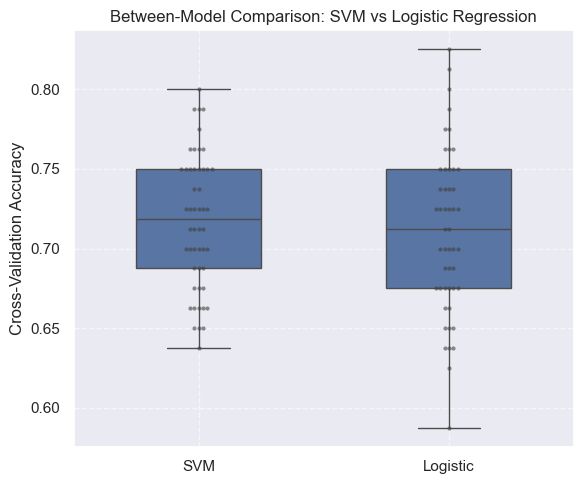

In [84]:
## Create box-plot comparison
# Convert to long format for plotting
resamp_long = resamp_df.melt(var_name="Model", value_name="Accuracy")

# Boxplot comparison
plt.figure(figsize=(6, 5))
sns.boxplot(x="Model", y="Accuracy", data=resamp_long, width=0.5)
sns.swarmplot(x="Model", y="Accuracy", data=resamp_long, color=".25", alpha=0.6, size=3)

plt.title("Between-Model Comparison: SVM vs Logistic Regression", fontsize=12)
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Exercises

### E: 4.1
Consider the music genre data set described in Sect. 1.4. The objective for these data is to use the predictors to classify music samples into the appropriate music genre.

(a) What data splitting method(s) would you use for these data? Explain.

Description of data from Sect. 1.4:

> In total, there were 12,495 music samples for which 191 characteristics were determined. The response categories were not balanced (Fig. 1.1), with the smallest segment coming from the heavy metal category (7 %) and the largest coming from the classical category (28 %). All predictors were continuous; many were highly correlated and the predictors spanned different scales of measurement. This data collection was created using 60 performers from which 15–20 pieces of music were selected for each performer. Then 20 segments of each piece were parameterized in order to create the final data set. Hence, the samples are inherently not independent of each other.

Size considerations (Obtained from sect. 4.7):
> For large sample sizes, the differences between resampling methods become less pronounced, and computational efficiency increases in importance. Here, simple 10-fold cross-validation should provide acceptable variance, low bias, and is relatively quick to compute.

Class imbalance: Used stratified resampling.

Non-independence: Because samples from the same performer or piece are not independent, the data split must ensure that all segments from a single performer (or piece) stay within the same partition (either training or testing). This can be achieved using grouped splitting.

(b) Using tools described in this chapter, provide code for implementing your
approach(es).

The data set could unfortunately not be obtained. But to perform the training/test split, GroupShuffleSplit can be used:

```r
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1056)
```

This however does not ensure a stratified split. A workaround is to use StratifiedGroupKFold as such:

```r
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1056)
```

Use the first fold as the test set and the remaining as training set.

It is possible stick to GroupShuffleSplit for simplicities sake and rely on cross-validation (with StratifiedGroupKFold) to handle stratification during model tuning.
This is perfectly reasonable — the small imbalance in the hold-out test set is usually not a big deal.